In [1]:
from fastai.vision.all import *

In [2]:
learn = load_learner('v2pruned_plant_classifier.pkl')
# Load the DataLoaders
with open('v2pruned_dls.pkl', 'rb') as f:
    learn.dls = pickle.load(f)


In [3]:
print(len(learn.dls.valid_ds))

2297


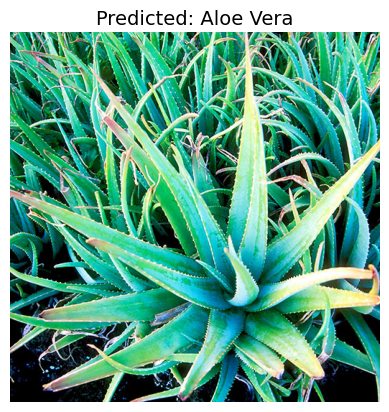

In [4]:
import matplotlib.pyplot as plt

# Load image
img_path = 'aloe1.jpg'
img = Image.open(img_path)

# Get prediction
pred_class, pred_idx, probs = learn.predict(img_path)

# Display image with predicted class
plt.imshow(img)
plt.axis('off')  # Hide axis
plt.title(f'Predicted: {pred_class}', fontsize=14, color='black')  # Show prediction
plt.show()

In [22]:
import cv2
from PIL import Image

# Initialize webcam (use index 0 for default camera)
cap = cv2.VideoCapture(0)

# Check if the webcam is opened correctly
if not cap.isOpened():
    print("Error: Could not access the camera.")
    exit()

# Capture a single frame from the webcam
ret, frame = cap.read()

if ret:
    # Save the captured image
    image_path = "captured_image.jpg"
    cv2.imwrite(image_path, frame)
    
    # Close the webcam
    cap.release()

    # Use your model to make a prediction
    pred_class, pred_idx, outputs = learn.predict(image_path)

    print(f"Predicted class: {pred_class}")
    print(f"Prediction probabilities: {outputs}")
else:
    print("Error: Failed to capture an image.")





Predicted class: Aloe Vera
Prediction probabilities: TensorBase([1.6103e-05, 8.3383e-01, 5.9597e-05, 1.2208e-04, 2.9925e-04,
            1.7578e-04, 1.8783e-05, 7.2045e-03, 1.3343e-04, 1.7373e-04,
            3.0994e-05, 3.5425e-05, 5.4976e-04, 1.6354e-03, 3.7010e-04,
            1.7868e-04, 7.7046e-05, 2.7862e-04, 3.1735e-05, 2.9996e-05,
            3.7744e-05, 3.9638e-05, 1.3638e-04, 2.7244e-05, 1.5667e-04,
            5.2213e-05, 1.8822e-05, 7.0630e-06, 1.4666e-04, 2.7280e-05,
            1.5389e-01, 5.0102e-05, 9.0623e-05, 7.0304e-05])


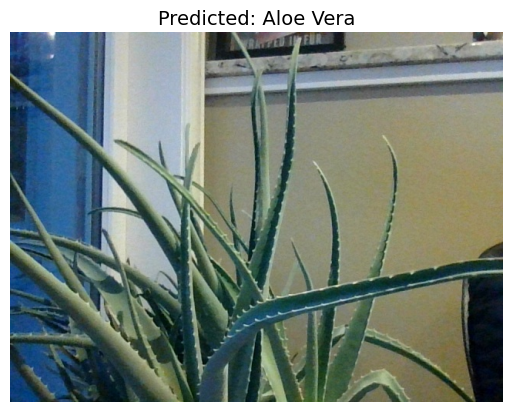

In [5]:
# Load image
img_path = 'captured_image.jpg'
img = Image.open(img_path)

# Get prediction
pred_class, pred_idx, probs = learn.predict(img_path)

# Display image with predicted class
plt.imshow(img)
plt.axis('off')  # Hide axis
plt.title(f'Predicted: {pred_class}', fontsize=14, color='black')  # Show prediction
plt.show()

In [6]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("ENDG511 Project Temps and Humidity.csv")

In [7]:
predicted_value = pred_class
# Find matching row
matching_row = df[df.iloc[:, 0] == predicted_value]
# Select specific columns (e.g., column 2 and 3)
selected_columns = matching_row.iloc[:, [3, 6]]

# Extracting temperature and humidty values
temp = selected_columns.iloc[0, 0]
hum = selected_columns.iloc[0, 1]

print('The Ideal Temperature is: ', temp)
print('The Ideal Humidity is: ', hum)

The Ideal Temperature is:  20
The Ideal Humidity is:  45


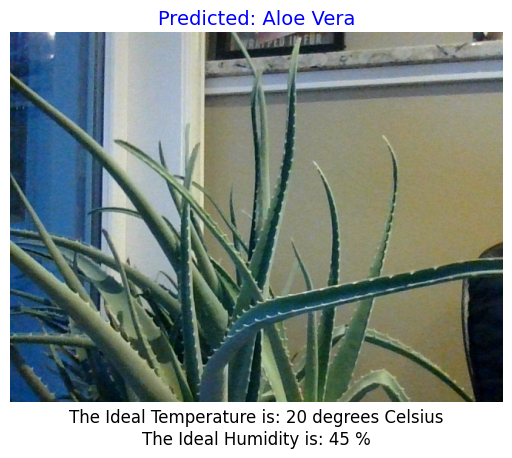

In [19]:
# Display image with predicted class
plt.imshow(img)
plt.axis('off')  # Hide axis
plt.title(f'Predicted: {pred_class}', fontsize=14, color='blue')  # Show prediction
plt.text(0.5, -0.04, f'The Ideal Temperature is: {temp} degrees Celsius', ha='center', va='center', fontsize=12, color='black', transform=plt.gca().transAxes)
plt.text(0.5, -0.1, f'The Ideal Humidity is: {hum} %', ha='center', va='center', fontsize=12, color='black', transform=plt.gca().transAxes)
plt.show()